# Import Libraries

In [1]:
import os
import time
import pickle
import random
import itertools

# Analisi dati e Visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    GridSearchCV,
    RandomizedSearchCV,
    ParameterGrid
)
from sklearn.pipeline import Pipeline

# Scikit-learn: Modelli di Machine Learning Classico
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import plot_tree

# Imbalanced Learning (SMOTE e Pipeline compatibile)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metriche di Valutazione
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

# Deep Learning (PyTorch) e Monitoraggio
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import datetime

# Our packages
from utils import *
from plot import *

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.compose import make_column_selector
from sklearn import set_config

set_config(transform_output="pandas")

# Global Variables

In [2]:
SEED = 42
FILENAME = "../../data/train.csv"

# Cerca la GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

No GPU acceleration available.


In [3]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(SEED)

# Load the dataset

In [4]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [5]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


##################################################
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction and train-test splitting

In [6]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

## 3. Pipeline

In [9]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """ Drop generic columns """
    def __init__(self, columns=[]):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class HighNanDropper(BaseEstimator, TransformerMixin):
    """ Rimuove colonne con alto numero di NaN"""
    
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.columns = []

    def fit(self, X, y=None):
        nan_ratio = X.isna().mean()
        self.columns = nan_ratio[nan_ratio > self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class HighlyCorrelatedDropper(BaseEstimator, TransformerMixin):
    """" Rimozione delle feature ridondanti identificate (High Correlation > threshold) """
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.columns = []

    def fit(self, X, y=None):
        numeric_df = X.select_dtypes(include=[np.number])
        corr_matrix = numeric_df.corr().abs()
        # Selezioniamo il triangolo superiore della matrice; k=1 esclude la diagonale principale
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns = [column for column in upper_tri.columns if any(upper_tri[column] > self.threshold)]
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class NumericExtractor(BaseEstimator, TransformerMixin):
    """ Estrae feature numeriche da stringhe (36/60 mesi, polishing anni di carriera...) """
    def __init__(self, columns=[]):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        valid_cols = [col for col in self.columns if col in X.columns]
        for col in valid_cols:
            X[col] = (X[col].astype(str)
                        .replace('< 1', '0') 
                        .str.extract(r"(\d+)")
                        .astype(float))
        return X
    
    
class FeatureAverager(BaseEstimator, TransformerMixin):
    """Media di n colonne e rimuove gli originali"""
    def __init__(self, columns=[], new_name='new_avg_col'):
        self.columns = columns
        self.new_name = new_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Calcoliamo la media lungo l'asse delle righe (axis=1)
        valid_cols = [col for col in self.columns if col in X.columns]
        if valid_cols:
            X[self.new_name] = X[valid_cols].mean(axis=1)
        return X.drop(columns=[col for col in self.columns if col in X.columns])

    
class DateDifferenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, reference_col, target_cols=None):
        self.reference_col = reference_col
        self.target_cols = target_cols or []
        self.date_format = '%b-%Y'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        # Check if reference exists
        if self.reference_col not in X.columns:
            return X # Skip if ref is missing (maybe dropped by NaN filter)

        ref_series = pd.to_datetime(X[self.reference_col], format=self.date_format, errors='coerce')
        
        # Ensure targets is a list and filter for existence
        targets = [self.target_cols] if isinstance(self.target_cols, str) else self.target_cols
        valid_targets = [col for col in targets if col in X.columns]
        
        cols_to_drop = []

        for col in valid_targets:
            target_series = pd.to_datetime(X[col], format=self.date_format, errors='coerce')
            new_col_name = f"months_since_{col}"

            X[new_col_name] = (
                (ref_series.dt.year - target_series.dt.year) * 12 +
                (ref_series.dt.month - target_series.dt.month)
            )
            X[new_col_name] = np.round(X[new_col_name]).astype('Int64')
            cols_to_drop.append(col)

        # Drop columns
        all_drops = cols_to_drop + [self.reference_col]
        # Final safety check before drop
        X = X.drop(columns=[c for c in all_drops if c in X.columns], errors='ignore')

        return X
    

class RoundToIntTransformer(BaseEstimator, TransformerMixin):
    """ Arrotonda le colonne selezionate all'intero piu vicino """
    def __init__(self, columns=[]):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in [c for c in self.columns if c in X.columns]:
                X[col] =  np.round(X[col]).astype('Int64')
        return X
    



In [10]:
loan_performance_data_leakage = [
    'loan_status_current_code',                         # prestito in regola, in ritardo, totalmente pagato...
    'outstanding_principal_balance',                    # "outstanding principal" e' la parte del capitale da restituire
    'outstanding_principal_investor_side',              # similmente
    'total_payment_received',                           # somma pagata al creditore
    'total_payment_investor_side',
    'total_received_principal',                         # somma pagata al creditore che copre la il capitale del prestito
    'total_received_interest',                          # ... copre gli interessi
    'total_received_late_fees',                         # ... copre le penali
    'recoveries_cash',                                  # somma recuperata dopo un prestito andato in default
    'collection_recovery_fee',                          # spese per il recupero crediti
    'last_payment_date',                                # data ultimo pagamento effettuato
    'last_payment',                                     # importo ultimo pagamento
    'next_payment_date',                                # data prossimo pagamento
    'last_credit_pull_date',                            # data ultimo check profilo creditizio, durante il periodo di prestito
    'last_fico_score_high_bound',                       # ultimo punteggio FICO rilevato: al momento della concessione del prestito si usa 'fico_score_low_bound', 'fico_score_high_bound
    'last_fico_score_low_bound',
    'total_collection_amount',
    'loan_payment_installments_count'                   # potrebbe semprare il numero di rate, ma la tipologia di valori contenuti fa pensare al valore economico della singola rata (calcolo derivante di interest rate)
]

# Il tasso di interesse di un prestito è calcolato basandosi sul Grading assegnato al prestito stesso.
# Essendo una conseguenza del nostro target "grade", è da considerarsi data leakage
# https://www.airtel.in/blog/personal-loan/how-does-loan-grading-work/ (Accessed 02/02/2026)
loan_contract_interest_rate = [
    'loan_contract_interest_rate'
]

# "Settlement" indica una situazione avvenuta durante / dopo il prestito, non al momento della concessione
settlement_data_leakage = [
    'debt_settlement_flag_indicator',
    'settlement_status_label',
    'settlement_amount_total', 
    'settlement_percentage', 
    'settlement_term_months'
]

# "Hardship loans" sono concessioni per agevolare il pagamento di un prestito quando il debitore si trova in momenti di difficoltà economica (perdita lavoro, problemi medici, disastri naturali)
# https://www.oaic.gov.au/privacy/your-privacy-rights/credit-reporting/hardship-assistance/what-is-a-financial-hardship-arrangement
# https://financialrights.org.au/factsheet/financial-hardship/
hardship_data_leakage = [
    'hardship_flag_indicator',
    'hardship_type_label',
    'hardship_reason_label',
    'hardship_status_label',
    'hardship_deferral_term_months',
    'hardship_amount_total',
    'hardship_duration_days',
    'hardship_days_past_due',
    'hardship_loan_status_label',
    'hardship_payoff_balance',
    'hardship_last_payment_amount_total'
]

other_leakage = [
    'original_projected_additional_accrued_interest',           # interesse addizionale previsto, presumibilmente in seguito a modifiche di piani ammortamento o hardship
    #'loan_issue_date',                                         # Il grade è influenzato dalla situazione creditizia del richiedente, più che dal periodo
                                                                # droppato in un secondo momento, dopo averlo usato per feature extraction
    'investor_side_funded_amount',
    'loan_portfolio_total_funded',
]

other_non_significant = [
    'platform_policy_code_id',                                      # id interno al prestatore
    'loan_title',                                                   # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
    'borrower_address_zip',                                         # non significant column, esiste una colonna per identificazione stati
]

####################################################################################################
joint_and_secondary_cols = [
    'joint_income_annual',
    'joint_dti_ratio',
    'joint_income_verification_status',
    'joint_revolving_balance',
    'secondary_applicant_fico_low',
    'secondary_applicant_fico_high',
    'secondary_applicant_earliest_credit_line',
    'secondary_applicant_inquiries_6m',
    'secondary_applicant_mortgage_accounts',
    'secondary_applicant_open_accounts',
    'secondary_applicant_revolving_utilization',
    'secondary_applicant_open_active_installment_loans',
    'secondary_applicant_revolving_accounts',
    'secondary_applicant_chargeoffs_12m',
    'secondary_applicant_collections_12m_ex_med',
    'secondary_applicant_months_since_last_major_derog'
]

####################################################################################################
number_from_string_cols = [
    'loan_contract_term_months',            # 36 mesi / 60 mesi
    'borrower_profile_employment_length',   # < 1 years, 10+ years
]

average_cols = [
    'fico_score_low_bound',
    'fico_score_high_bound'
]

date_diff_reference = 'loan_issue_date'
date_diff_target = [ 'credit_history_earliest_line' ]

####################################################################################################

# Lista delle feature che richiedono valori interi: conteggi di linee di credito e conti, mesi, fico score
round_to_nearest_int = [
    # Months
    'loan_contract_term_months',
    'months_since_last_delinquency',
    'months_since_last_public_record',
    'months_since_last_major_derog',
    'months_since_recent_installment_loan',
    'months_since_oldest_installment_acct',
    'months_since_oldest_revolving_acct',
    'months_since_recent_revolving_acct',
    'months_since_recent_trade_line',
    'months_since_recent_bankcard',
    'months_since_recent_bankcard_delinquency',
    'months_since_recent_inquiry',
    'months_since_recent_revolving_delinquency',
    'months_since_credit_history_earliest_line',

    # account, eventi, inquiry, delinquency
    'credit_delinquencies_2yrs',
    'credit_inquiries_6m',
    'credit_open_accounts',
    'credit_public_records',
    'collections_12m_ex_med',
    'accounts_now_delinquent',
    'open_accounts_6m',
    'open_active_installment_loans',
    'open_installment_loans_12m',
    'open_installment_loans_24m',
    'open_revolving_accounts_12m',
    'open_revolving_accounts_24m',
    'finance_inquiries',
    'credit_union_trades_total',
    'credit_inquiries_12m',
    'accounts_open_past_24m',
    'chargeoffs_within_12m',
    'mortgage_accounts',
    'accounts_ever_120dpd',
    'active_bankcard_tradelines',
    'active_revolving_tradelines',
    'bankcard_satisfactory_accounts',
    'bankcard_tradelines',
    'installment_tradelines',
    'open_revolving_tradelines',
    'revolving_accounts',
    'tradelines_120dpd_2m',
    'tradelines_30dpd',
    'tradelines_90dpd_24m',
    'tradelines_open_past_12m',
    'public_record_bankruptcies',
    'tax_liens_total',

    'borrower_profile_employment_length',
    'fico_average'

]

####################################################################################################

categorical_to_unknown_cols = [
  'borrower_address_state',
  'loan_purpose_category',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

fill_big_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency', 
    'months_since_recent_inquiry', 
    'months_since_recent_bankcard',
    'months_since_recent_trade_line'
]

fill_zero_cols = [
    'open_accounts_6m', 'open_installment_loans_12m', 'open_installment_loans_24m',
    'open_revolving_accounts_12m', 'open_revolving_accounts_24m',
    'finance_inquiries', 'credit_inquiries_12m', 'credit_union_trades_total',
    'open_active_installment_loans', 'tradelines_open_past_12m', 'accounts_open_past_24m',
    'open_revolving_tradelines', 'active_bankcard_tradelines', 'installment_tradelines',
    'revolving_accounts', 'bankcard_satisfactory_accounts', 'active_revolving_tradelines', 
    'bankcard_tradelines', 'credit_open_accounts', 'credit_total_accounts',
    'tradelines_120dpd_2m', 'tradelines_30dpd', 'tradelines_90dpd_24m',
    'accounts_ever_120dpd', 'chargeoffs_within_12m', 'collections_12m_ex_med',
    'accounts_now_delinquent', 'public_record_bankruptcies', 'credit_public_records',
    'credit_delinquencies_2yrs', 'tax_liens_total', 'borrower_profile_employment_length'
]

fill_to_mode_cat = [
    'disbursement_method_type',
    'application_type_label',
    'listing_initial_status',
    'loan_payment_plan_flag'         # n/y
]

fill_to_mode_num = [
    'loan_contract_term_months'    # 36/60 mesi
]

In [11]:
remainder_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('impute_unknown', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_to_unknown_cols),
        ('impute_0', SimpleImputer(strategy='constant', fill_value=0), fill_zero_cols),
        ('impute_10k', SimpleImputer(strategy='constant', fill_value=999), fill_big_cols),
        ('impute_mode_cat',SimpleImputer(strategy='most_frequent'), fill_to_mode_cat),
        ('impute_mode_num', SimpleImputer(strategy='most_frequent'), fill_to_mode_num),
    ],
    remainder=remainder_pipeline,
    verbose_feature_names_out=False
)


encoding = ColumnTransformer(
    transformers=[
        # Applica categorical_pipe a TUTTE le colonne di tipo object o category
        ('cat_step', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(dtype_include=['object'])),
    ], 
    # Tutto ciò che è numerico e non è stato toccato sopra, viene scalato qui
    remainder="passthrough", 
    verbose_feature_names_out=False
)

In [12]:

full_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(columns = loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    ('drop_non_significant', ColumnDropper(columns = other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    ('drop_joint_and_secondary', ColumnDropper(columns = joint_and_secondary_cols)),
    ('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns = number_from_string_cols)),
    ('fico_average', FeatureAverager(columns = average_cols)),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns = round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),
    
    ("clf", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
])

param_grid_rf = {
    #'clf__n_estimators': [250, 300],
    #'clf__criterion': ['gini', 'log_loss'],
    #'clf__max_depth': [10, 20]
}

scoring = {
    'acc': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'f1_weighted': 'f1_weighted'
}

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring='balanced_accuracy',
    #refit='balanced_acc', 
    error_score='raise',
    n_jobs=-1,
    verbose=3
)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


KeyboardInterrupt: 

In [ ]:
import pickle

# 1. Recuperiamo il miglior stimatore
full_best_pipeline = grid.best_estimator_

print("Migliori parametri:", grid.best_params_)
print(f"Miglior CV Score: {grid.best_score_:.4f}")

# 2. Dividiamo la Pipeline
# [:-1] prende tutto tranne l'ultimo step ('clf')
preprocessing_part = full_best_pipeline[:-1] 
# Accediamo al classificatore tramite il suo nome 'clf'
classifier_part = full_best_pipeline.named_steps['clf']

# 3. Salvataggio (Uso .pkl o .joblib per convenzione)
try:
    with open("rf_preprocessor.save", "wb") as f:
        pickle.dump(preprocessing_part, f)

    with open("rf.save", "wb") as f:
        pickle.dump(classifier_part, f)
        
    print("\nFile salvati correttamente:")
    print("- 'rf_preprocessor.save' (Contiene tutti i drop e le trasformazioni)")
    print("- 'rf.save' (Contiene solo il RandomForestClassifier allenato)")
except Exception as e:
    print(f"Errore durante il salvataggio: {e}")

Migliori parametri: {}
Miglior CV Score: 0.3226

File salvati correttamente:
- 'rf_preprocessor.save' (Contiene tutti i drop e le trasformazioni)
- 'rf.save' (Contiene solo il RandomForestClassifier allenato)


REPORT VALUTAZIONE: RF
Workflow rilevato: Preprocessor (Custom Pipeline)
Parametri RF: n_estimators=100, max_depth=None, class_weight=balanced
----------------------------------------

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.70      0.66      0.68      6634
           1       0.44      0.57      0.50      9435
           2       0.37      0.53      0.43      9270
           3       0.26      0.12      0.17      5314
           4       0.30      0.12      0.17      3021
           5       0.33      0.13      0.19      1881
           6       0.40      0.16      0.23      1521

    accuracy                           0.44     37076
   macro avg       0.40      0.33      0.34     37076
weighted avg       0.42      0.44      0.41     37076

Accuracy Score:          0.4377
Balanced Accuracy Score: 0.3282


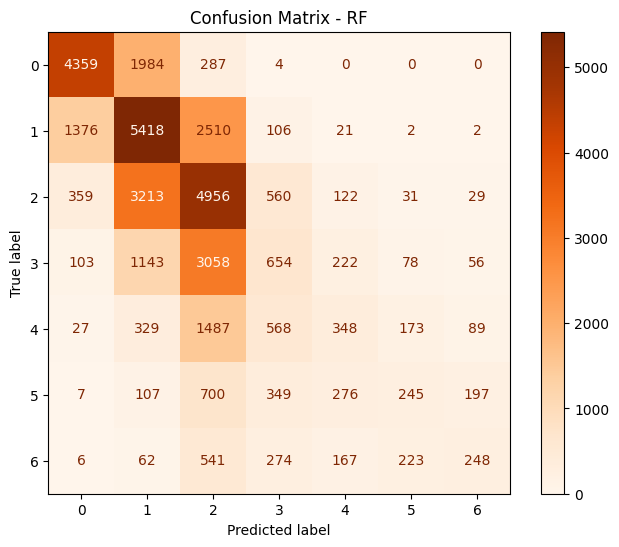

In [13]:
evaluate_model(X_val, y_val, "rf")